In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [28]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [29]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [30]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [31]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
# 1. One-hot encode the categorical columns and save it to a new DataFrame
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

This ensures that we have all numerical data only for the model.

To ensure that the values of all the weights are converged, we scale the values.

In [33]:
# 2. Separate your features (X) and target (y) using the encoded DataFrame
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [34]:
X_train.shape

(8000, 11)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
X_train_scaled

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [37]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [38]:
model = Sequential()

#hidden layer has 3 perceptrons
model.add(Dense(11, activation='relu', input_dim = 11))
model.add(Dense(11, activation='relu'))
#output layer
model.add(Dense(1, activation= 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=10)

In [41]:
history = model.fit(X_train_scaled, y_train, batch_size=50, epochs=100, verbose=1, validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5342 - loss: 0.7021 - val_accuracy: 0.7969 - val_loss: 0.5443
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8001 - loss: 0.5219 - val_accuracy: 0.7969 - val_loss: 0.4764
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7907 - loss: 0.4762 - val_accuracy: 0.8044 - val_loss: 0.4422
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8087 - loss: 0.4297 - val_accuracy: 0.8138 - val_loss: 0.4250
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8174 - loss: 0.4125 - val_accuracy: 0.8188 - val_loss: 0.4146
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8295 - loss: 0.3989 - val_accuracy: 0.8256 - val_loss: 0.4050
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8275 - loss: 0.4021 - val_accuracy: 0.8294 - val_loss: 0.3960
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8422 - loss: 0.3753 - val_accu

In [42]:
model.layers[0].get_weights()

[array([[ 0.75775   , -0.14662601, -0.07688333,  0.18569328, -0.11377792,
         -0.39759696,  0.0249431 , -0.00626532, -0.27277136, -0.14441572,
          0.07976718],
        [-0.00281135, -0.8107639 ,  0.6399974 ,  0.1421257 , -0.53171647,
         -0.25888172,  0.06864034, -0.8016001 ,  0.6319632 ,  0.30816197,
         -0.68544525],
        [-0.21499254,  0.29820463, -0.20049797,  0.2589877 , -0.04747418,
         -0.49675518, -0.08673377, -0.12304193,  0.07996287, -0.07479795,
          0.04839857],
        [-0.4115473 , -0.45364457,  0.19368464, -0.24879588,  0.0355423 ,
          0.08571524,  0.46028593,  0.37943533, -0.31946176, -0.28241178,
         -0.01310802],
        [ 0.69337785,  0.11887568,  0.09853497,  0.4212043 ,  0.19702427,
          0.41661948,  1.2832513 ,  0.2495838 ,  0.16179737, -1.0310775 ,
          0.02607267],
        [-0.19344077,  0.35654998,  0.3628132 ,  0.30039316, -0.18570875,
          0.19197758, -0.05227854, -0.20097634, -0.13184543,  0.0187487

In [43]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [44]:
y_pred = y_pred.argmax(axis=-1)

In [45]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7975

In [46]:
import matplotlib.pyplot as plt

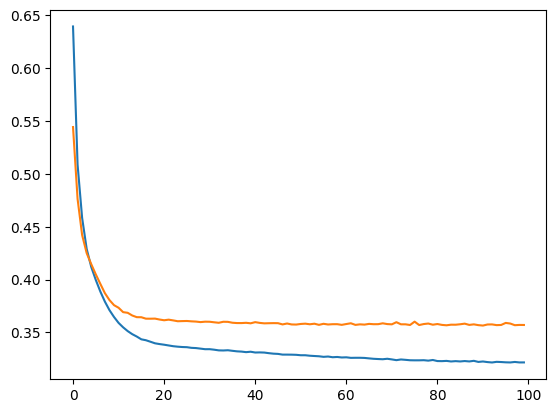

In [47]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

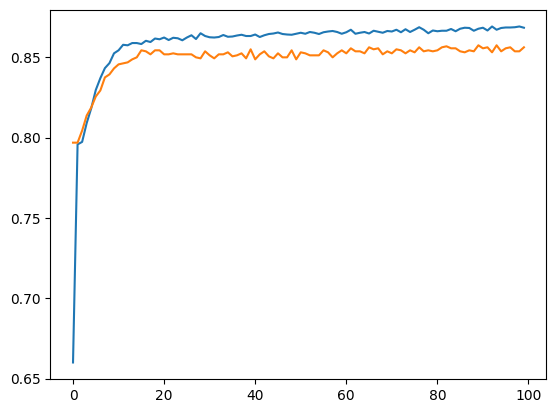

In [48]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])